## 1. Preprocessing Data

2 universes to look at the data
1. yield (lbs/ft) over season
2. rate over season

rate is noisy as we don't have direct measurements and yield samples can be over various times. Not consistently taken.
But we can model kelp's growth rate based on the day of season that acts as a proxy for environmental factors (amount of light, temperature).
Modeling yield allows us to incorporate the outplanting date where GreenWave notes that an earlier date usually means a better harvest outcome.
These are related. The derivative of the yield curve should look similar to the rate curve.
Both suffer from a lack of data after harvesting... what is happening to kelp growth then?

sample and harvest are at different scales based on differences in measurement. Sample is a ft of line. Harvest is what actually comes off line. Both selected by the farmer but at very different scales. Both can be represented as lbs/ft but need to rescale harvest based on a factor learned from comparing sample yields to harvest yields.

Farmers are instructed to take ~3 samples across their farm every month. These same day samples carries information on measurement or biological noise which could inform the noise around the model's prediction/curve. Also, it gives you more information about where the growth/yield could be going in the future- encodes some level of uncertainity aboout the belief.


We will be organizing the data into groups of same farm-season-species with their sample events (observations) of lbs/ft
- outplant = 0 lbs/ft
- sample = weight / 1 ft
- harvest = weight / line length (scaled to sample if on the same plot)

Sugar kelp will be the only species analyzed.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.stats import gaussian_kde, lognorm, norm, truncnorm
from scipy.stats import t as student_t

# MCMC engine (only imported inside posterior_mcmc, so the rest of the
# notebook runs without it): pip install pymc arviz


In [2]:
XLSX = "/Users/gracegibson/work/green_wave/greenwave/20260724_kcf_export_anonymized.xlsx"
GROUP = ["Farm Name", "Season", "Species"]
LINE_TOLERANCE = 0.0
MODEL_SPECIES = "sugar_kelp"
MIN_FARMS_PER_REGION = 3

In [3]:
def day_of_season(ts) -> int:
    """ Days since Oct 1. Kelp follows the calendar not the seed date."""
    ts = pd.Timestamp(ts)
    oct1 = pd.Timestamp(year=ts.year if ts.month >= 10 else ts.year - 1,
                            month=10, day=1)
    return (ts - oct1).days

def build_events(path: str) -> pd.DataFrame:
    logs = pd.read_excel(path, sheet_name="Logs")
    logs["Log Date"] = pd.to_datetime(logs["Log Date"]).dt.normalize()
    logs.dropna(subset=["Log Date"], inplace=True)

    outplant = logs[logs["Log Type"] == "outplanting"].copy()
    samples = logs[logs["Log Type"] == "sample"].copy()
    harvest = logs[logs["Log Type"] == "harvest"].copy()

    loss_types = [t for t in logs["Log Type"].dropna().unique()
                      if "loss" in str(t).lower()]
    loss = logs[logs["Log Type"].isin(loss_types)].copy()

    # get the total line outplanted, lost, and harvested in a farm-season
    # not a running total but the final amounts
    grp_outplant = (outplant.groupby(GROUP)
        .agg(seed_date=("Log Date", "min"),
             last_outplant_date=("Log Date", "max"),
             n_outplant_dates=("Log Date", "nunique"),
             outplant_line_ft=("Line Length", "sum")).reset_index())
    grp_harvest = (harvest.dropna(subset=["Weight"]).groupby(GROUP)
        .agg(true_biomass_lbs=("Weight", "sum"),
             harvest_line_ft=("Line Length", "sum"),
             n_harvests=("Weight", "size")).reset_index())
    grp_loss = (loss.groupby(GROUP).agg(loss_line_ft=("Line Length", "sum"))
                .reset_index()
                if len(loss) else pd.DataFrame(columns=GROUP + ["loss_line_ft"]))
    grp_outplant["outplant_spread_days"] = grp_outplant["last_outplant_date"] - grp_outplant["seed_date"]
    group_biomass = (grp_outplant.merge(grp_harvest, on=GROUP, how="left")
                          .merge(grp_loss, on=GROUP, how="left"))
    group_biomass["loss_line_ft"] = group_biomass["loss_line_ft"].fillna(0.0)
    group_biomass["available_line_ft"] = group_biomass["outplant_line_ft"] - group_biomass["loss_line_ft"]
    group_biomass["flag_single_outplant"] = group_biomass["n_outplant_dates"] == 1
    group_biomass["n_harvests"] = group_biomass["n_harvests"].fillna(0.0)
    group_biomass["flag_has_harvest"] = group_biomass["n_harvests"] > 0
    group_biomass["flag_harvest_within_available"] = ~group_biomass["flag_has_harvest"] | (
            group_biomass["harvest_line_ft"] <= group_biomass["available_line_ft"] * (1 + LINE_TOLERANCE))

    # add the state (region) per farm group
    farm_state = logs[["Farm Name", "State"]].dropna().drop_duplicates("Farm Name")
    group_biomass = group_biomass.merge(farm_state, on="Farm Name", how="left")
    sugar_kelp_groups = group_biomass[group_biomass["Species"] == MODEL_SPECIES]
    farms_per_state = sugar_kelp_groups.groupby("State")["Farm Name"].nunique()
    valid_states = farms_per_state[farms_per_state >= MIN_FARMS_PER_REGION].index
    group_biomass["flag_region_ok"] = group_biomass["State"].isin(valid_states)

    # add observation events
    outplant_ev = (outplant[GROUP + ["Log Date"]].assign(lbs_ft=0.0, event="outplant"))
    sample_ev = (samples.dropna(subset=["Weight"])[GROUP + ["Log Date", "Weight"]]
                .rename(columns={"Weight": "lbs_ft"})
                .assign(event="sample", line_ft=1.0))
    sample_ev["weight_lbs"] = sample_ev["lbs_ft"]  # samples are per 1 ft
    harvest_ev = harvest.dropna(subset=["Weight", "Line Length"]).copy()
    harvest_ev = harvest_ev[harvest_ev["Line Length"] > 0] # something had to be harvested
    harvest_ev["lbs_ft"] = harvest_ev["Weight"] / harvest_ev["Line Length"]
    # keep the raw pieces: line_ft turns a lbs/ft forecast back into pounds,
    # weight_lbs is the per-event biomass ground truth
    harvest_ev["line_ft"] = harvest_ev["Line Length"]
    harvest_ev["weight_lbs"] = harvest_ev["Weight"]
    harvest_ev = harvest_ev[GROUP + ["Log Date", "lbs_ft", "line_ft",
                                     "weight_lbs"]].assign(event="harvest")
    events = pd.concat([outplant_ev, sample_ev, harvest_ev], ignore_index=True)
    events["is_outplant"] = events["event"] == "outplant"

    # add its farm-season biomass information to each event
    events = events.merge(group_biomass, on=GROUP, how="left")
    # filter only to sugar kelp and fill in rest of flags + day of season
    events["flag_model_species"] = events["Species"] == MODEL_SPECIES
    events["flag_has_outplant_date"] = events["seed_date"].notna()
    for c in ["flag_single_outplant", "flag_has_harvest",
              "flag_harvest_within_available", "flag_region_ok"]:
        events[c] = events[c].fillna(False).astype(bool)
    events["day_of_season"] = events["Log Date"].apply(day_of_season)
    events["flag_after_seed"] = events["is_outplant"] | (
            events["Log Date"] > events["seed_date"])
    events["farm_season_id"] = (
            events["Farm Name"].str.replace("Farm_", "F") + "_"
            + events["Season"].str.replace("Season ", "").str.replace("/", ""))
    return events


In [4]:
events = build_events(XLSX)

/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_19979/2774718344.py:79: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events[c] = events[c].fillna(False).astype(bool)
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_19979/2774718344.py:79: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events[c] = events[c].fillna(False).astype(bool)
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_19979/2774718344.py:79: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versi

In [5]:
# filter events 
FILTERS = [
    (f"species == {MODEL_SPECIES}", "flag_model_species"),
    ("group has an outplanting log", "flag_has_outplant_date"),
    ("harvest line <= outplant - loss", "flag_harvest_within_available"),
    ("event after seed date", "flag_after_seed"),
]
# keep groups with multiple outplanting because it's common
# and can't detangle outplant lines to samples to harvests. a single harvest event is likely a mixture of outplant lines
# or one line but can't determine which one
# samples could be taken from the same line or multiple lines but may not cover all possible lines
# both samples and harvests are a blend of all the outplanted lines

# the curve fitting gives a weighted average outplant but growth starts as soon as the first outplanting
# do not drop "outliers" - very high or low yields per a farm season because the data is true, the model is what we're
# uncertain about in bayesian statistics
# keep all region/states for now...
print(f"total:    {len(events)} events  {events.groupby(GROUP).ngroups} groups")
for name, flag_col in FILTERS:
    events = events[events[flag_col]]
    print(f"{name:38s} {len(events):5d} events "
            f"{events.groupby(GROUP).ngroups:4d} groups")

total:    2654 events  281 groups
species == sugar_kelp                   1778 events  166 groups
group has an outplanting log            1775 events  165 groups
harvest line <= outplant - loss         1564 events  155 groups
event after seed date                   1561 events  155 groups


In [6]:
# Curve definitions -- interchangeable, and module-agnostic: the m=
# argument lets the SAME function run under numpy (fitting, SIR, plots)
# and pytensor (PyMC MCMC, where we pass m=pt so gradients flow through).
def logistic(t, A, k, t0, m=np):
    """Symmetric sigmoid. A=plateau, k=growth rate, t0=inflection day."""
    return A / (1.0 + m.exp(-k * (t - t0)))

def gompertz(t, A, k, t0, m=np):
    """Asymmetric sigmoid (long RIGHT taper: fast start, slow finish).
    Same parameter names, but note k and t0 are NOT numerically
    comparable to logistic's."""
    return A * m.exp(-m.exp(-k * (t - t0)))

def weibull(t, A, k, t0, m=np):
    """Asymmetric sigmoid mirroring Gompertz (long LEFT taper: slow
    start, fast finish): A * (1 - exp(-exp(k (t - t0)))).  The exponent
    is clipped so t far past t0 saturates instead of overflowing."""
    return A * (1.0 - m.exp(-m.exp(m.minimum(k * (t - t0), 30.0))))

def monomolecular(t, A, k, t0, m=np):
    """Saturating growth with NO inflection: zero until t0, fastest
    growth immediately at t0, decaying toward the plateau A.  (von
    Bertalanffy-style; tests whether the data even wants a sigmoid.)"""
    return A * m.maximum(1.0 - m.exp(m.minimum(-k * (t - t0), 30.0)), 0.0)

CURVES = {"logistic": logistic, "gompertz": gompertz,
          "weibull": weibull, "monomolecular": monomolecular}

In [7]:
YCOL = "lbs_ft"
TCOL = "day_of_season"
IDCOL = "farm_season_id"

SAMPLE_EVENT = "sample"      # value in `event` column for growth samples
HARVEST_EVENT = "harvest"    # value in `event` column for harvests
MIN_SAMPLES = 3              # skip seasons with fewer sample points than this

def fit_one_season_to_curve(t, y, th=None, yh=None, curve="logistic"):
    ""
    f = CURVES[curve]
    t, y = np.asarray(t, float), np.asarray(y, float)
    # separate harvests from samples. On different scales due to measurement differences
    has_h = th is not None and yh is not None and len(np.atleast_1d(th)) > 0
    if has_h:
        th, yh = np.asarray(th, float), np.asarray(yh, float)
    # Data driven initialization of curve parameters
    ymax = y.max()
    A0 = ymax * 1.2
    # t0 guess: day of steepest observed increase in y
    # good enough guess is the median amongst all samples
    order = np.argsort(t)
    t_sorted, y_sorted = t[order], y[order]
    t0_0 = float(np.median(t_sorted))

    # k -growth rate parameter
    k0 = 0.05 # assume very little lbs/ft growth per day
    c0 = 0.65 # prior belief about the harvest/sample scale from history

    # Bounds for parameters... what's realistic and want to flag if outside
    # A must be positive and probably not 3x outside all observations
    # k must be positive for growth rate
    # t0   
    lo = [1e-3, 1e-4, t_sorted.min()-100]
    hi = [3.0 * max(ymax, 0.1), 1.0, t_sorted.max()+100]
    x0 = [A0, k0, t0_0]
    if has_h:
        lo, hi, x0 = lo + [0.1], hi + [3.0], x0 + [c0]
    x0 = np.clip(x0, lo, hi)
    f_scale = max(0.1 * ymax, 1e-3)



    def resid(p):
        if has_h:
            A_, k_, t0_, c_ = p
            return np.concatenate([f(t, A_, k_, t0_) - y,
                                   c_ * f(th, A_, k_, t0_) - yh])
        return f(t, *p) - y
 
    try:
        res = least_squares(resid, x0, bounds=(lo, hi), loss="soft_l1",
                            f_scale=f_scale, max_nfev=5000)
        if has_h:
            A, k, t0, c = res.x
            rh = c * f(th, A, k, t0) - yh
        else:
            (A, k, t0), c, rh = res.x, np.nan, np.array([])
        r = f(t, A, k, t0) - y  # sample residuals only -> sample-scale sigma
        # Robust residual scale (MAD-based) as the sigma proxy
        sigma = 1.4826 * np.median(np.abs(r - np.median(r))) if len(r) > 2 \
            else float(np.std(r))
        sigma_h = (1.4826 * np.median(np.abs(rh - np.median(rh)))
                   if len(rh) > 2 else
                   (float(np.std(rh)) if len(rh) else np.nan))
        rmse = float(np.sqrt(np.mean(r ** 2)))
        converged = bool(res.success)
    except Exception:
        A = k = t0 = c = sigma = sigma_h = rmse = np.nan
        converged = False
 
    # --- identifiability / quality diagnostics -----------------------------
    # Plateau is informed if OBSERVATIONS (samples or harvests) continued
    # past the inflection by ~one timescale.
    t_obs_max = max(t_sorted.max(), th.max()) if has_h else t_sorted.max()
    plateau_seen = bool(np.isfinite(t0) and
                        t_obs_max > t0 + (1.0 / max(k, 1e-6)))
    # A far above anything observed => extrapolated plateau. Judge this on
    # the SAMPLE scale only: converting harvests via the fitted c would be
    # circular (a degenerate c would launder a degenerate A past the check).
    a_ratio = float(A / ymax) if np.isfinite(A) and ymax > 0 else np.nan
 
    # t0 pinned at the edge of its allowed window = optimizer ran away,
    # a classic sign the sigmoid shape isn't identified by this season.
    t0_at_bound = bool(np.isfinite(t0) and
                       (t0 <= lo[2] + 1 or t0 >= hi[2] - 1))
    # c pinned at its bound = scale not identified (usually: harvests are
    # the only late-season evidence, so c and A trade off).
    c_at_bound = bool(has_h and np.isfinite(c) and
                      (c <= 0.1 + 1e-3 or c >= 3.0 - 1e-3))
    # The A-c split is only trustworthy if SAMPLES pinned the curve's bend;
    # harvests alone can't separate "high plateau, low c" from the reverse.
    samples_saw_bend = bool(np.isfinite(t0) and
                            t_sorted.max() > t0 + (1.0 / max(k, 1e-6)))
 
    ok = (converged and np.isfinite(a_ratio) and not t0_at_bound
          and not c_at_bound and len(y) >= MIN_SAMPLES
          and (samples_saw_bend or a_ratio < 2.0))
    return dict(A=A, k=k, t0=t0, c=c, sigma=sigma, sigma_h=sigma_h,
                rmse=rmse, n_samples=len(y),
                n_harvests=int(len(yh)) if has_h else 0,
                converged=converged, plateau_seen=plateau_seen,
                samples_saw_bend=samples_saw_bend,
                A_over_ymax=a_ratio, t0_at_bound=t0_at_bound,
                c_at_bound=c_at_bound,
                quality=("ok" if ok else "flag"))

def build_parameter_cloud(df, curve="logistic"):
    """Fit every farm-season; return one tagged row per season."""
    samples = df[df["event"] == SAMPLE_EVENT].dropna(subset=[YCOL, TCOL])
    harvests = df[df["event"] == HARVEST_EVENT].dropna(subset=[YCOL, TCOL])
    rows = []
    for fsid, g in samples.groupby(IDCOL):
        if len(g) < MIN_SAMPLES:
            continue
        h = harvests[harvests[IDCOL] == fsid]
        fit = fit_one_season_to_curve(g[TCOL], g[YCOL],
                             th=h[TCOL].values if len(h) else None,
                             yh=h[YCOL].values if len(h) else None,
                             curve=curve)
        meta = g.iloc[0]
        fit.update({
            IDCOL: fsid,
            "farm": meta["Farm Name"],
            "season": meta["Season"],
            "state": meta["State"],
            "outplant_spread_days": meta.get("outplant_spread_days", np.nan),
            "n_outplant_dates": meta.get("n_outplant_dates", np.nan),
            "single_outplant": meta.get("flag_single_outplant", np.nan),
            "curve": curve,
        })
        rows.append(fit)
    cloud = pd.DataFrame(rows)
    return cloud.sort_values("rmse", ascending=False).reset_index(drop=True)
 
 
# ---------------------------------------------------------------------------
# Visualization — small multiples, worst fits first
# ---------------------------------------------------------------------------
def plot_fits(df, cloud, curve="logistic", ncols=4, max_plots=None,
              savepath=None):
    f = CURVES[curve]
    samples = df[df["event"] == SAMPLE_EVENT]
    harvests = df[df["event"] == HARVEST_EVENT]
    outplants = df[df["is_outplant"] == True]  # noqa: E712
 
    plot_cloud = cloud if max_plots is None else cloud.head(max_plots)
    n = len(plot_cloud)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows),
                             squeeze=False)
 
    for ax, (_, row) in zip(axes.flat, plot_cloud.iterrows()):
        fsid = row[IDCOL]
        g = samples[samples[IDCOL] == fsid]
        h = harvests[harvests[IDCOL] == fsid]
        o = outplants[outplants[IDCOL] == fsid]
 
        # Outplant events as green squares at y=0 (biomass starts at ~zero):
        # shows where the season began and, for multi-outplant farms, how
        # staggered the plantings were.
        odays = sorted(o[TCOL].dropna().unique())
        if odays:
            ax.scatter(odays, np.zeros(len(odays)), marker="s", s=45,
                       color="tab:green", zorder=4, label="outplant")
 
        ax.scatter(g[TCOL], g[YCOL], s=18, color="tab:blue", zorder=3,
                   label="samples")
        if len(h):
            ax.scatter(h[TCOL], h[YCOL], marker="*", s=120,
                       color="tab:orange", zorder=4, label="harvest")
 
        # Extend the curve well past the last sample so extrapolated
        # plateaus (unidentified A) are visually obvious; start it early
        # enough to cover the first outplant.
        t_end = max(g[TCOL].max(), h[TCOL].max() if len(h) else 0) + 30
        t_start = min(g[TCOL].min(),
                      o[TCOL].min() if len(o) else g[TCOL].min(), 0)
        tt = np.linspace(t_start, t_end, 200)
        if np.isfinite(row["A"]):
            yy = f(tt, row["A"], row["k"], row["t0"])
            ax.plot(tt, yy, color="tab:red", lw=1.5, zorder=2)
            ax.axhline(row["A"], color="tab:red", ls=":", lw=0.8, alpha=0.6)
            # Harvest-scale curve c*f(t): what the fit predicts a HARVEST
            # measurement would read — the stars should track this line.
            if np.isfinite(row.get("c", np.nan)):
                ax.plot(tt, row["c"] * yy, color="tab:orange", lw=1.2,
                        ls="--", zorder=2)
 
        tag = "" if row["quality"] == "ok" else "  ⚠"
        c_txt = (f" c={row['c']:.2f}"
                 if np.isfinite(row.get("c", np.nan)) else "")
        ax.set_title(f"{row['farm'][:18]} {row['season']}{tag}\n"
                     f"A={row['A']:.2f} k={row['k']:.3f} "
                     f"t0={row['t0']:.0f}{c_txt} n={row['n_samples']}",
                     fontsize=8)
        ax.set_xlabel("day of season", fontsize=7)
        ax.set_ylabel(YCOL, fontsize=7)
        ax.tick_params(labelsize=7)
 
    for ax in axes.flat[n:]:
        ax.axis("off")
 
    fig.suptitle(f"Per-season {curve} fits (sorted worst RMSE first; "
                 f"⚠ = flagged)", y=1.001)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    # Render exactly once: show explicitly, then close so notebook
    # backends don't re-display the open figure at cell end, and return
    # None so the figure object isn't echoed as a cell output either.
    plt.show()
    plt.close(fig)
 
 
# ---------------------------------------------------------------------------
# Cloud-level view: where do the parameters land?
# ---------------------------------------------------------------------------
def plot_cloud(cloud, savepath=None):
    ok = cloud[cloud["quality"] == "ok"]
    bad = cloud[cloud["quality"] != "ok"]
    has_c = "c" in cloud.columns and cloud["c"].notna().any()
    pairs = [("t0", "A"), ("t0", "k"), ("k", "A")]
    if has_c:
        pairs += [("c", "A"), ("c", "sigma_h")]
    fig, axes = plt.subplots(1, len(pairs), figsize=(4.3 * len(pairs), 4))
    for ax, (x, y) in zip(np.atleast_1d(axes), pairs):
        ax.scatter(bad[x], bad[y], s=25, color="lightgray", label="flagged")
        ax.scatter(ok[x], ok[y], s=25, color="tab:blue", label="ok")
        ax.set_xlabel(x); ax.set_ylabel(y)
        if x == "c":
            ax.axvline(0.65, color="tab:orange", ls=":", lw=1,
                       label="c=0.65" if y == "A" else None)
    np.atleast_1d(axes)[0].legend(fontsize=8)
    fig.suptitle("Parameter cloud — this is what the KDE prior will smooth")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [8]:
# ---------------- model configuration: every switch in one place ----------
YIELD_CURVE      = "logistic"   # "logistic" | "gompertz"
C_PARAM          = "two_curve"  # "two_curve" (mu_h = c*f)  |  "offset" (mu = f*(1+kappa*is_harvest))
PRIOR_METHOD     = "kde"        # "kde" (smooth historical fits) | "broad" (population ranges, no fitting)
PRIOR_FALLBACK   = "kde"        # population fallback when a farm has too little history: "kde" | "broad"
POSTERIOR_METHOD = "sir"        # "sir" (fast importance resampling) | "mcmc" (PyMC NUTS)
STRICT_TEMPORAL  = False        # True: population fallback also drops other farms' same/later seasons
MCMC_KW          = dict(draws=1000, tune=1000, chains=2)
NU               = 4            # Student-t dof: heavy tails shrug off a bad sample
save_plots_prefix = "v2"

Fitted 98 farm-seasons with logistic. 36 flagged for review.


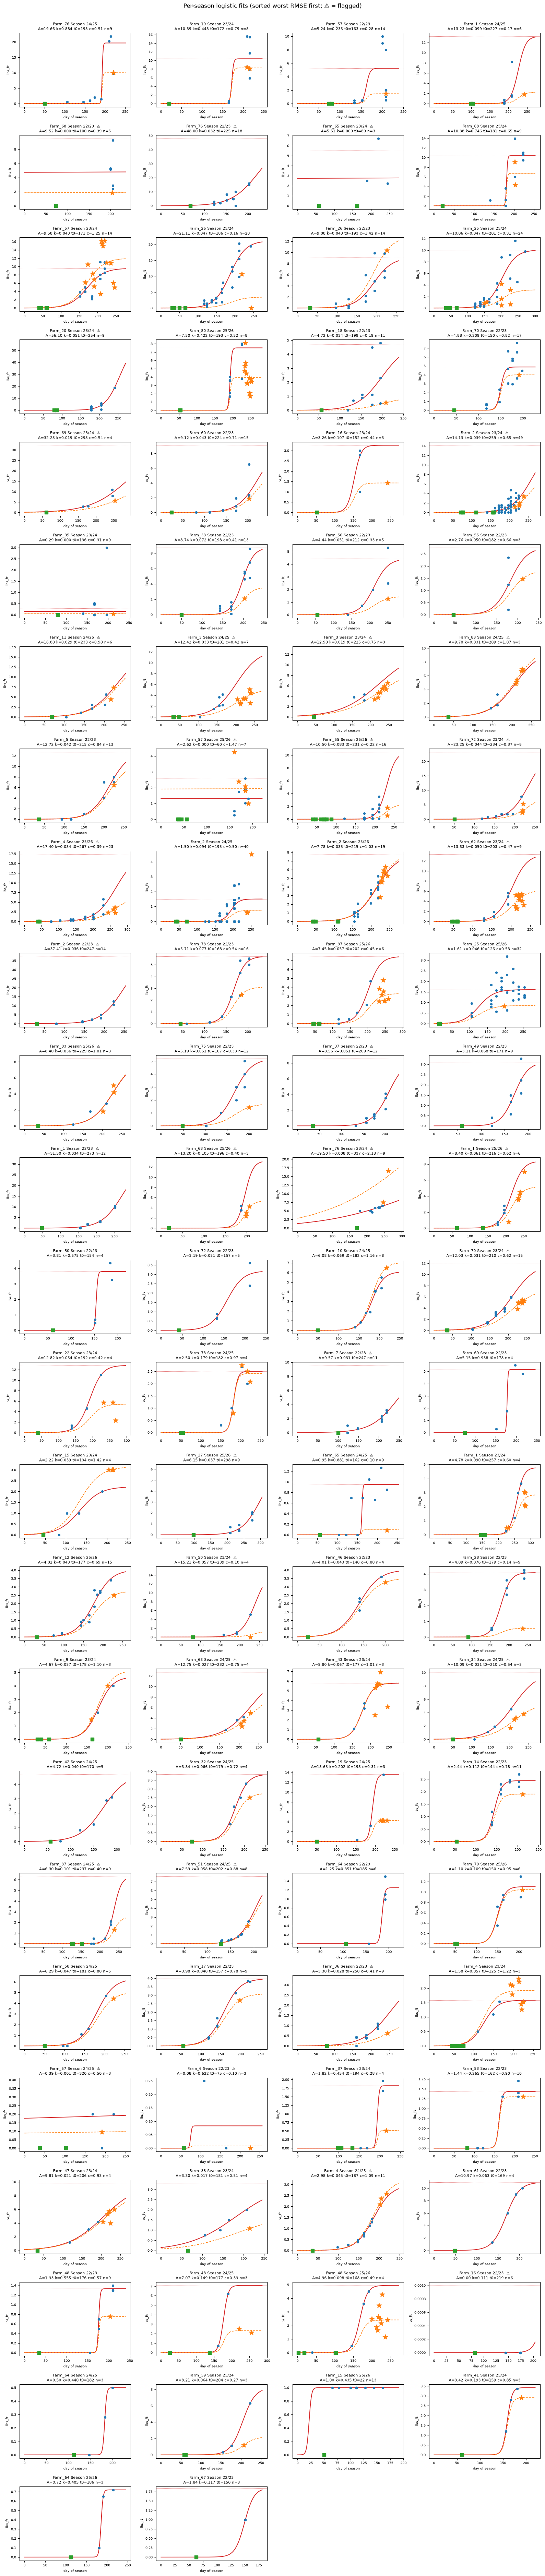

In [9]:
cloud = build_parameter_cloud(events, curve=YIELD_CURVE)
print(f"Fitted {len(cloud)} farm-seasons with {YIELD_CURVE}. "
          f"{(cloud['quality'] != 'ok').sum()} flagged for review.")
plot_fits(events, cloud, curve=YIELD_CURVE,
              savepath=f"{save_plots_prefix}_{YIELD_CURVE}_fits.png")

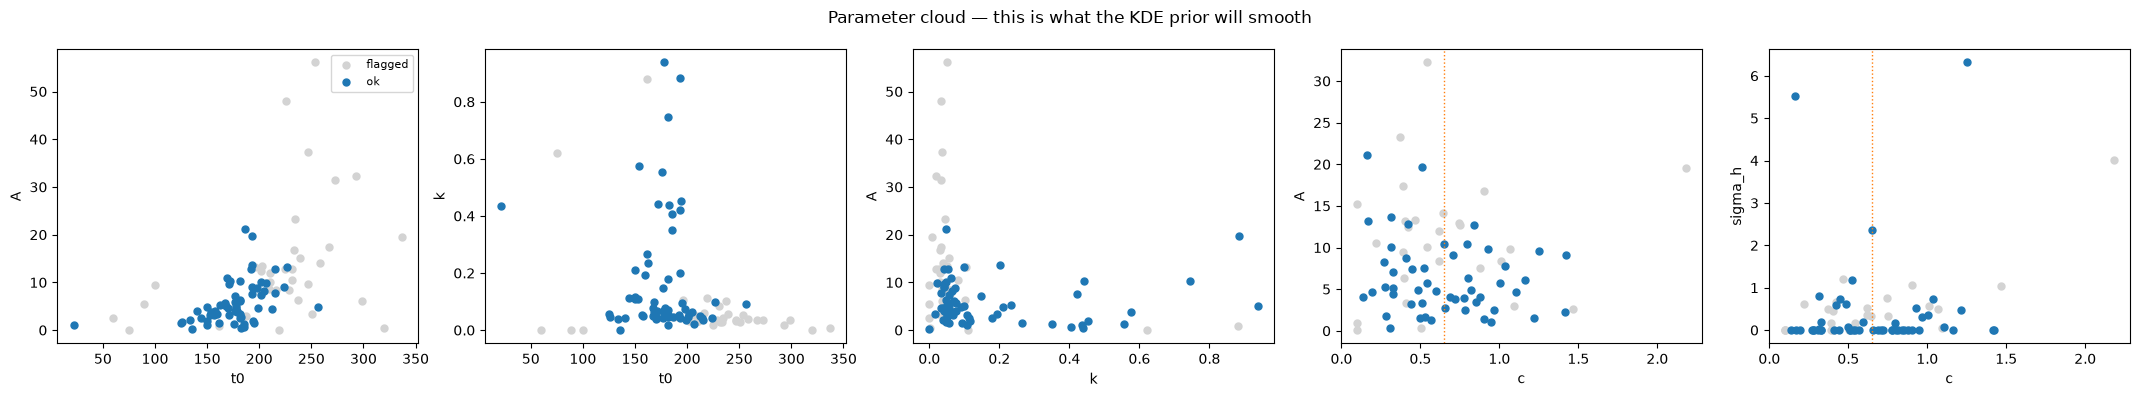

In [10]:
plot_cloud(cloud)

In [11]:
cloud.columns

Index(['A', 'k', 't0', 'c', 'sigma', 'sigma_h', 'rmse', 'n_samples',
       'n_harvests', 'converged', 'plateau_seen', 'samples_saw_bend',
       'A_over_ymax', 't0_at_bound', 'c_at_bound', 'quality', 'farm_season_id',
       'farm', 'season', 'state', 'outplant_spread_days', 'n_outplant_dates',
       'single_outplant', 'curve'],
      dtype='object')

## 2. Priors — two interchangeable constructions, resolved per farm

A prior here is just a dict `{param: spec}` that both the SIR sampler and
the PyMC model builder know how to consume, so everything downstream is
agnostic to where the prior came from. Two ways to build one:

**`"kde"` (original approach).** Fit every historical farm-season to a
curve, smooth the resulting parameter cloud with one KDE per parameter.
Sharp and data-driven, but inherits every pathology of the per-season
fits (the suspect high-k seasons leak into the prior), and it uses the
data twice when the same seasons later appear in a backtest.

**`"broad"` (new).** A weakly-informative parametric prior describing
plausible values across the *whole population* of farms and seasons —
chosen from domain knowledge (kelp plateaus are lbs-not-tons per ft,
inflection lands mid-winter-to-spring, harvests read below samples),
not from fitting this dataset. It concedes sharpness in exchange for
robustness: no dependence on least-squares fits, no double-use of the
data, and the season's own observations do all the narrowing. The
numbers in `BROAD_PRIOR_CONFIG` are *config, not truth* — sanity-check
the implied ranges against `plot_cloud()` and adjust.

**Farm-specific resolution (`make_prior_for_farm`).** The prior for a
target season is now built from *that farm's own strictly-earlier
seasons* when it has at least `min_seasons` of them — not the whole
cloud. Farms without enough history fall back to the population
(`"kde"` on everyone else with the target season excluded, or
`"broad"`). This is a pragmatic step toward the hierarchical model:
farm-level information enters through the prior rather than through a
shared farm-effect parameter.

In [12]:

# ---------------------------------------------------------------------------
# Harvest-scale parameterization: two interchangeable options.
#
#   "two_curve": mu_harvest = c * f(t).  c is its own positive parameter
#                (prior centered on history, e.g. ~0.65).  The model is two
#                curves sharing a shape: the sample curve and its scaled twin.
#
#   "offset":    mu = f(t) * (1 + kappa * is_harvest).  kappa is a signed
#                offset with prior centered on 0 ("null = no scale gap"),
#                so the DATA has to pull the harvest scale away from the
#                sample scale.  Identical likelihood via c = 1 + kappa; the
#                difference is where the prior puts its mass and how the
#                parameter reads ("-0.35" = harvests read 35% low).
# ---------------------------------------------------------------------------
SCALE_PARAM = {"two_curve": "c", "offset": "kappa"}

def harvest_scale(draws, c_param):
    """Multiplicative harvest scale per posterior/prior draw."""
    if c_param == "two_curve":
        return draws["c"]
    return 1.0 + draws["kappa"]

# ---------------------------------------------------------------------------
# Priors — a prior is a dict {param: spec}; spec is one of
#   {"kind": "kde",       "kde": gaussian_kde, "log": bool}
#   {"kind": "lognormal", "mu": float, "sigma": float}          (log-space)
#   {"kind": "normal",    "mu": float, "sigma": float}
#   {"kind": "truncnorm", "mu": float, "sigma": float, "lo": float}
# plus a "_meta" entry describing provenance.  Both the SIR sampler and the
# PyMC model builder consume this one format, so priors are interchangeable.
# ---------------------------------------------------------------------------
PARAMS_BASE = ["A", "k", "t0", "sigma", "sigma_h"]
LOG_PARAMS = {"A", "k", "c", "sigma", "sigma_h"}

# Broad population prior: plausible values across ALL farms and seasons,
# chosen from domain knowledge, not fit to this dataset.  SANITY-CHECK the
# ranges against plot_cloud() and adjust — they are config, not truth.
BROAD_PRIOR_CONFIG = {
    # central 95% ranges implied by (mu, sigma) in log space:
    "A":       {"kind": "lognormal", "mu": np.log(4.0),  "sigma": 0.80},  # ~0.8-19 lbs/ft plateau
    "k":       {"kind": "lognormal", "mu": np.log(0.05), "sigma": 0.75},  # ~0.011-0.22 per day
    "t0":      {"kind": "normal",    "mu": 150.0,        "sigma": 45.0},  # inflection late Dec-May
    "c":       {"kind": "lognormal", "mu": np.log(0.65), "sigma": 0.35},  # ~0.33-1.3 harvest/sample
    "kappa":   {"kind": "truncnorm", "mu": 0.0,          "sigma": 0.35, "lo": -0.95},
    "sigma":   {"kind": "lognormal", "mu": np.log(0.5),  "sigma": 0.80},  # sample noise lbs/ft
    "sigma_h": {"kind": "lognormal", "mu": np.log(0.5),  "sigma": 0.80},
}

def make_prior_broad(c_param="two_curve", config=None):
    cfg = dict(BROAD_PRIOR_CONFIG)
    if config:
        cfg.update(config)
    params = PARAMS_BASE + [SCALE_PARAM[c_param]]
    prior = {p: dict(cfg[p]) for p in params}
    prior["_meta"] = {"method": "broad", "source": "population (domain ranges)",
                      "c_param": c_param}
    return prior

def make_prior_kde(cloud, c_param="two_curve"):
    """One KDE per parameter from ok-quality historical fits (original
    approach).  For c_param='offset' the fitted c is re-expressed as
    kappa = c - 1 and smoothed in raw space."""
    good = cloud[cloud["quality"] == "ok"]
    prior = {}
    for p in PARAMS_BASE + [SCALE_PARAM[c_param]]:
        sub = good
        col = "c" if p == "kappa" else p
        if p == "sigma_h" and "n_harvests" in good:
            sub = good[good["n_harvests"] >= 3]
        vals = sub[col].dropna().to_numpy()
        if p == "kappa":
            vals = vals - 1.0
        if p in LOG_PARAMS:
            vals = np.log(vals[vals > 0])
        prior[p] = {"kind": "kde",
                    "kde": gaussian_kde(vals) if len(vals) >= 2 else None,
                    "log": p in LOG_PARAMS}
    prior["_meta"] = {"method": "kde", "source": f"{len(good)} historical fits",
                      "c_param": c_param}
    return prior

def _season_sort_key(season):
    """'Season 23/24' -> 2023 so seasons order chronologically."""
    digits = "".join(ch for ch in str(season) if ch.isdigit())
    return int(digits[:2]) + 2000 if len(digits) >= 2 else -1

def make_prior_for_farm(cloud, farm, before_season=None, method="kde",
                        c_param="two_curve", min_seasons=3, fallback="kde",
                        strict_temporal=False, verbose=True):
    """Farm-specific prior: built from THIS farm's earlier seasons when it
    has enough of them, falling back to the population otherwise.

    before_season : the season being predicted; only strictly-earlier
        seasons of this farm are used (no peeking at the target season).
    method        : 'kde' (smooth the farm's own fits) or 'broad'
        (skip history entirely; farm arg then only matters via fallback).
    fallback      : 'kde' (population KDE, target season excluded) or
        'broad' when the farm has < min_seasons of usable history.
    strict_temporal : if True the population fallback also drops OTHER
        farms' seasons from the target year onward (no future leakage
        into the backtest).
    """
    if method == "broad":
        prior = make_prior_broad(c_param=c_param)
        prior["_meta"]["source"] = "population (broad, no history)"
        return prior

    cutoff = _season_sort_key(before_season) if before_season else None
    own = cloud[(cloud["farm"] == farm) & (cloud["quality"] == "ok")]
    if cutoff is not None:
        own = own[own["season"].map(_season_sort_key) < cutoff]

    if len(own) >= min_seasons:
        prior = make_prior_kde(own, c_param=c_param)
        prior["_meta"]["source"] = (f"farm {farm}: {len(own)} earlier seasons")
        # a single farm rarely has >=3 seasons with >=3 harvests each, so
        # sigma_h / c KDEs can come back None; patch from population
        pop = cloud[cloud["farm"] != farm] if before_season is None else \
              cloud[~((cloud["farm"] == farm) &
                      (cloud["season"].map(_season_sort_key) >= cutoff))]
        pop_prior = make_prior_kde(pop, c_param=c_param)
        for p, spec in prior.items():
            if p != "_meta" and spec.get("kde") is None:
                prior[p] = pop_prior[p]
                prior["_meta"]["source"] += f" (+population {p})"
        return prior

    # fallback: population, always excluding the target season itself
    pop = cloud
    if before_season is not None:
        pop = pop[~((pop["farm"] == farm) & (pop["season"] == before_season))]
        if strict_temporal:
            pop = pop[pop["season"].map(_season_sort_key) < cutoff]
    if verbose:
        print(f"  {farm}: only {len(own)} earlier seasons "
              f"(< {min_seasons}) -> {fallback} population fallback")
    if fallback == "broad":
        return make_prior_broad(c_param=c_param)
    prior = make_prior_kde(pop, c_param=c_param)
    prior["_meta"]["source"] = f"population KDE ({len(pop)} seasons, target excluded)"
    return prior

# ---------------------------------------------------------------------------
# Sampling any prior (drives SIR and all the fan plots)
# ---------------------------------------------------------------------------
def sample_prior(prior, n=4000, rng=None):
    rng = np.random.default_rng(rng)
    out = {}
    for p, spec in prior.items():
        if p == "_meta":
            continue
        kind = spec["kind"]
        if kind == "kde":
            if spec["kde"] is None:
                out[p] = np.full(n, np.nan)
            else:
                v = spec["kde"].resample(n, seed=rng)[0]
                out[p] = np.exp(v) if spec["log"] else v
        elif kind == "lognormal":
            out[p] = lognorm(s=spec["sigma"], scale=np.exp(spec["mu"])).rvs(n, random_state=rng)
        elif kind == "normal":
            out[p] = norm(spec["mu"], spec["sigma"]).rvs(n, random_state=rng)
        elif kind == "truncnorm":
            a = (spec["lo"] - spec["mu"]) / spec["sigma"]
            out[p] = truncnorm(a, np.inf, loc=spec["mu"], scale=spec["sigma"]).rvs(n, random_state=rng)
        else:
            raise ValueError(kind)
    return out

In [13]:
def plot_prior(prior, cloud=None, n=20000):
    """Each prior marginal (drawn by sampling, so it works for KDE and
    broad priors alike), with the historical fitted values as a rug when
    a cloud is given."""
    draws = sample_prior(prior, n)
    params = [p for p in draws if np.isfinite(draws[p]).any()]
    fig, axes = plt.subplots(1, len(params), figsize=(3.6 * len(params), 3))
    for ax, p in zip(np.atleast_1d(axes), params):
        v = draws[p][np.isfinite(draws[p])]
        logscale = p in LOG_PARAMS and (v > 0).all()
        if logscale:
            grid = np.logspace(np.log10(v.min()), np.log10(v.max()), 300)
            ax.plot(grid, gaussian_kde(np.log(v))(np.log(grid)),
                    color="tab:purple", lw=2)
            ax.set_xscale("log")
        else:
            grid = np.linspace(v.min(), v.max(), 300)
            ax.plot(grid, gaussian_kde(v)(grid), color="tab:purple", lw=2)
        if cloud is not None:
            col = "c" if p == "kappa" else p
            if col in cloud:
                hv = cloud.loc[cloud["quality"] == "ok", col].dropna()
                hv = hv - 1.0 if p == "kappa" else hv
                ax.plot(hv, np.zeros(len(hv)), "|", ms=18, color="tab:blue")
        ax.set_title(f"prior for {p}", fontsize=9)
        ax.set_yticks([])
    fig.suptitle(f"prior marginals  [{prior['_meta']['method']}: "
                 f"{prior['_meta']['source']}]", y=1.04)
    fig.tight_layout()
    plt.show(); plt.close(fig)


def plot_prior_curves(prior, curve_name, n_curves=100, t_max=280):
    """The prior as curves: red = sample scale, dashed orange = harvest
    scale (via whichever c-parameterization is configured)."""
    f = CURVES[curve_name]
    t = np.linspace(0, t_max, 200)
    d = sample_prior(prior, n=n_curves)
    sc = harvest_scale(d, prior["_meta"]["c_param"])
    fig, ax = plt.subplots(figsize=(8, 5))
    for i in range(n_curves):
        y = f(t, d["A"][i], d["k"][i], d["t0"][i])
        ax.plot(t, y, color="tab:red", alpha=0.12, lw=1)
        if np.isfinite(sc[i]):
            ax.plot(t, sc[i] * y, color="tab:orange", alpha=0.12, lw=1, ls="--")
    ax.set_xlabel("day of season"); ax.set_ylabel("lbs_ft")
    ax.set_title(f"{n_curves} seasons drawn from the prior "
                 f"[{prior['_meta']['method']}]\n"
                 "(red = sample scale, dashed = harvest scale)")
    fig.tight_layout(); plt.show(); plt.close(fig)

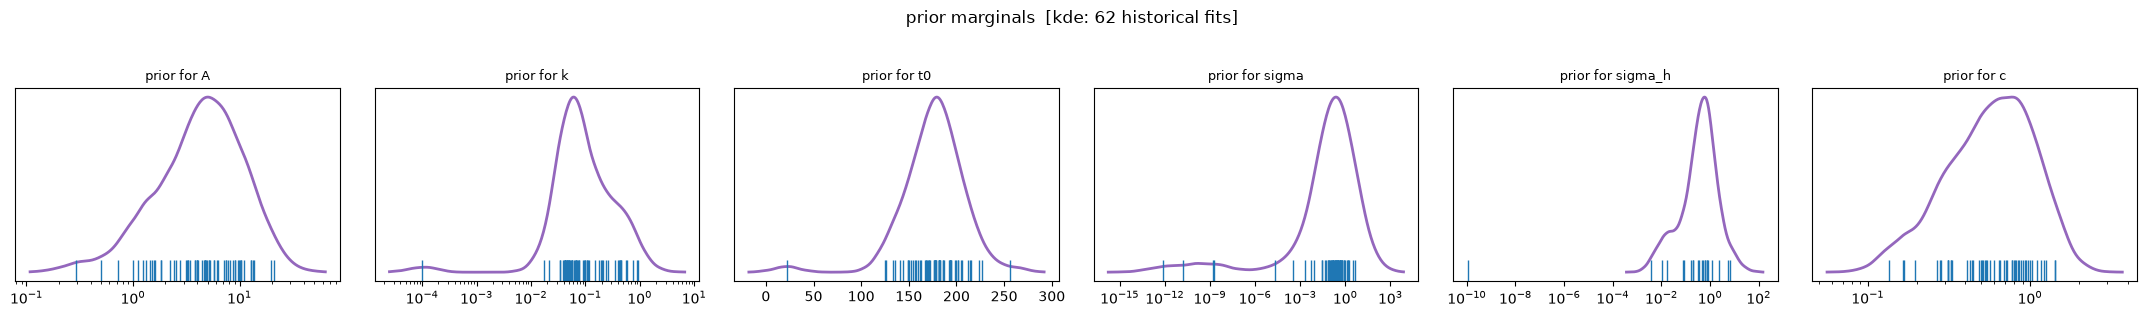

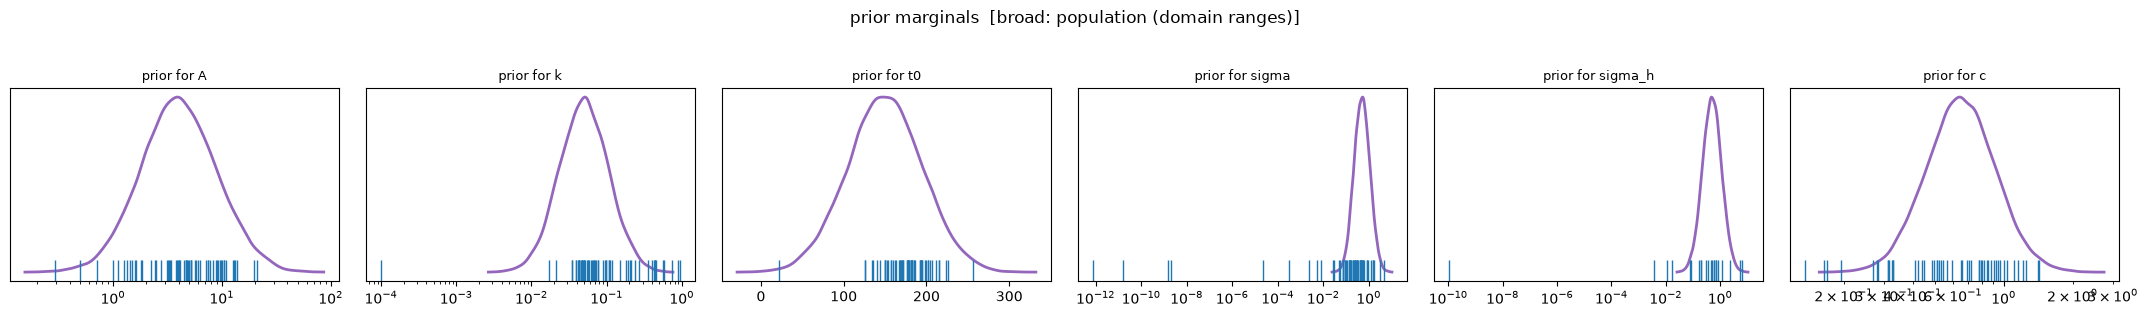

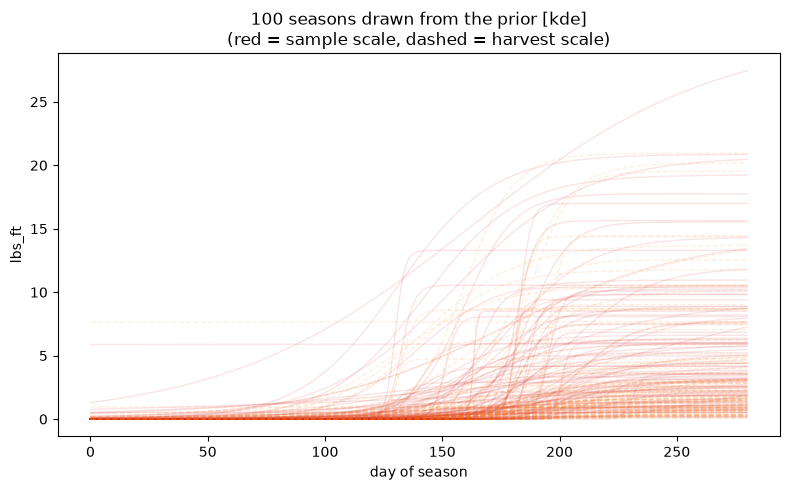

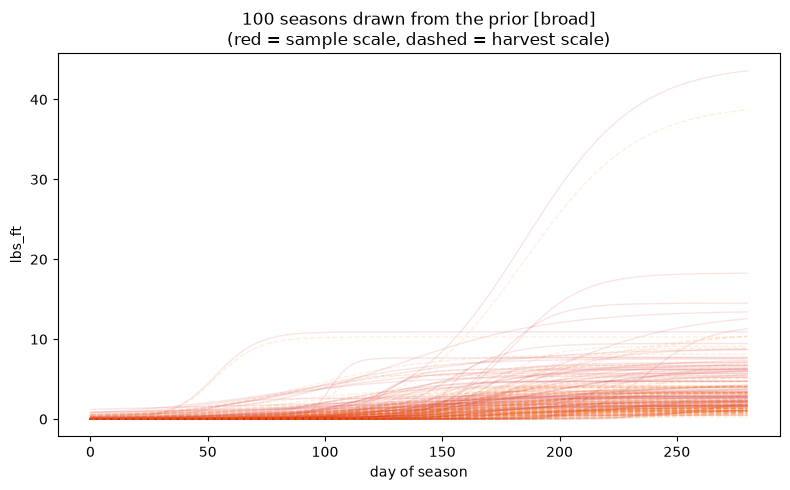

In [14]:
# population-level priors, both ways — compare them before trusting either
prior_kde   = make_prior_kde(cloud, c_param=C_PARAM)
prior_broad = make_prior_broad(c_param=C_PARAM)
plot_prior(prior_kde, cloud)
plot_prior(prior_broad, cloud)   # rug = history; the broad prior should COVER it comfortably
plot_prior_curves(prior_kde, YIELD_CURVE)
plot_prior_curves(prior_broad, YIELD_CURVE)

## 3. The harvest/sample scale: two parameterizations of the same idea

Both options say the farm has **one** underlying growth curve `f(t)` and
harvests read it at a different scale. They differ only in how that
scale is written and where its prior sits:

- **`"two_curve"`** — `mu_sample = f(t)`, `mu_harvest = c · f(t)`, with
  `c` a positive parameter whose prior comes from history (KDE) or is
  centered near 0.65 (broad). Reads naturally as "the harvest curve is
  the sample curve times c".
- **`"offset"`** — one regression-style mean,
  `mu = f(t) · (1 + κ · is_harvest)`, with κ's prior centered at **0**.
  The null hypothesis is "no scale gap", and the data has to *earn* the
  departure; the posterior κ ≈ −0.35 then reads directly as "harvests
  measure 35% low". Since samples are the reference channel,
  `is_harvest` (not `is_sample`) carries the offset — flipping the
  indicator would put the calibration uncertainty on the channel we
  trust most.

Mathematically `c = 1 + κ`, so with matched priors the two are the same
model. The practical differences: (1) prior shrinkage — offset shrinks
toward *no* gap, two-curve shrinks toward the *historical* gap; (2) the
offset form extends naturally if more indicator features enter later
(e.g. per-region or per-gear terms). Switch via `C_PARAM` and compare —
close agreement is itself evidence the scale factor is data-identified
rather than prior-driven.

## 4. Posterior — one front door, two engines

`compute_posterior(..., method=)` dispatches to:

- **`"sir"`** — sampling-importance-resampling (original approach):
  draw a big batch from the prior, weight by the Student-t likelihood,
  resample. Fast, no compilation, but it can only ever return points
  the prior proposed — when the data drags the posterior into the
  prior's tails the weights concentrate on a few draws. **Watch `ess`**;
  below a few hundred, switch engines.
- **`"mcmc"`** — PyMC NUTS. Explores the posterior directly, so it
  stays reliable exactly where SIR degrades, at the cost of compiling
  and sampling per call. KDE priors enter PyMC as `Interpolated`
  marginals (independent per parameter — the same independence the SIR
  sampler already assumes, so both engines see the *same* prior; joint
  correlations are a future hierarchical step). **Check `rhat_max`
  ≤ ~1.01 and `divergences == 0`.**

Both return the same dict of draws, so every downstream plot and table
works with either.

In [15]:
# ---------------------------------------------------------------------------
# Posterior — one front door, two engines.
#
#   method="sir" : sampling-importance-resampling (fast, no compilation;
#                  degrades when the data drags the posterior far from the
#                  prior — watch 'ess').
#   method="mcmc": PyMC NUTS (slower per call, but explores the posterior
#                  directly; check 'rhat_max' ~<= 1.01 and divergences == 0).
# ---------------------------------------------------------------------------
def compute_posterior(prior, curve_name, t, y, th=None, yh=None,
                      method="sir", c_param="two_curve", **kw):
    if method == "sir":
        return posterior_sir(prior, curve_name, t, y, th, yh,
                             c_param=c_param, **kw)
    if method == "mcmc":
        return posterior_mcmc(prior, curve_name, t, y, th, yh,
                              c_param=c_param, **kw)
    raise ValueError(f"unknown posterior method {method!r}")

def posterior_sir(prior, curve_name, t, y, th=None, yh=None,
                  c_param="two_curve", n_prior=200_000, n_post=4000, rng=0):
    curve_fn = CURVES[curve_name]
    rng = np.random.default_rng(rng)
    d = sample_prior(prior, n=n_prior, rng=rng)
    t, y = np.asarray(t, float), np.asarray(y, float)
    logL = np.zeros(n_prior)
    if len(t):
        mu = curve_fn(t[None, :], d["A"][:, None], d["k"][:, None],
                      d["t0"][:, None])
        logL = student_t.logpdf(y[None, :], NU, loc=mu,
                                scale=d["sigma"][:, None]).sum(axis=1)
    if th is not None and yh is not None and len(np.atleast_1d(th)) > 0:
        th, yh = np.asarray(th, float), np.asarray(yh, float)
        scale = harvest_scale(d, c_param)
        muh = scale[:, None] * curve_fn(th[None, :], d["A"][:, None],
                                        d["k"][:, None], d["t0"][:, None])
        sh = d["sigma_h"]
        if not np.isfinite(sh).any():
            sh = d["sigma"]
        logLh = student_t.logpdf(yh[None, :], NU, loc=muh,
                                 scale=sh[:, None]).sum(axis=1)
        logL = logL + np.nan_to_num(logLh, nan=-np.inf)
    if not np.isfinite(logL).any():
        raise ValueError("no prior draw has finite likelihood")
    logL -= logL.max()
    w = np.exp(logL)
    ess = float(w.sum() ** 2 / (w ** 2).sum())
    idx = rng.choice(n_prior, size=n_post, p=w / w.sum())
    post = {p: v[idx] for p, v in d.items()}
    post["ess"] = ess
    post["method"] = "sir"
    return post

def _add_pymc_prior(name, spec, pm, np_grid=400):
    """Turn one prior spec into a PyMC random variable of the same name."""
    kind = spec["kind"]
    if kind == "lognormal":
        return pm.LogNormal(name, mu=spec["mu"], sigma=spec["sigma"])
    if kind == "normal":
        return pm.Normal(name, mu=spec["mu"], sigma=spec["sigma"])
    if kind == "truncnorm":
        return pm.TruncatedNormal(name, mu=spec["mu"], sigma=spec["sigma"],
                                  lower=spec["lo"])
    if kind == "kde":
        kde = spec["kde"]
        if kde is None:
            raise ValueError(f"no KDE information for {name}")
        # Interpolated prior over the (log-)variable on a grid spanning the
        # KDE support.  NOTE: per-parameter Interpolated priors are
        # INDEPENDENT marginals — exactly what sample_prior() does for SIR,
        # so both engines see the same prior.  (Capturing the joint
        # correlations of the cloud is a future hierarchical-model step.)
        lo = kde.dataset.min() - 2 * kde.dataset.std()
        hi = kde.dataset.max() + 2 * kde.dataset.std()
        grid = np.linspace(lo, hi, np_grid)
        pdf = np.clip(kde(grid), 1e-300, None)
        if spec["log"]:
            raw = pm.Interpolated(f"log_{name}", grid, pdf)
            import pytensor.tensor as pt
            return pm.Deterministic(name, pt.exp(raw))
        return pm.Interpolated(name, grid, pdf)
    raise ValueError(kind)

def posterior_mcmc(prior, curve_name, t, y, th=None, yh=None,
                   c_param="two_curve", draws=1000, tune=1000, chains=2,
                   target_accept=0.9, rng=0, progressbar=False):
    import pymc as pm
    import pytensor.tensor as pt
    import arviz as az

    curve_fn = CURVES[curve_name]
    t, y = np.asarray(t, float), np.asarray(y, float)
    has_h = th is not None and yh is not None and len(np.atleast_1d(th)) > 0
    if has_h:
        th, yh = np.asarray(th, float), np.asarray(yh, float)
    scale_name = SCALE_PARAM[c_param]

    with pm.Model():
        A = _add_pymc_prior("A", prior["A"], pm)
        k = _add_pymc_prior("k", prior["k"], pm)
        t0 = _add_pymc_prior("t0", prior["t0"], pm)
        sigma = _add_pymc_prior("sigma", prior["sigma"], pm)
        if len(t):
            pm.StudentT("obs_s", nu=NU, mu=curve_fn(t, A, k, t0, m=pt),
                        sigma=sigma, observed=y)
        if has_h:
            sc_raw = _add_pymc_prior(scale_name, prior[scale_name], pm)
            scale = sc_raw if c_param == "two_curve" else 1.0 + sc_raw
            spec_h = prior["sigma_h"]
            usable = spec_h["kind"] != "kde" or spec_h["kde"] is not None
            sigma_h = _add_pymc_prior("sigma_h", spec_h, pm) if usable else sigma
            pm.StudentT("obs_h", nu=NU,
                        mu=scale * curve_fn(th, A, k, t0, m=pt),
                        sigma=sigma_h, observed=yh)
        idata = pm.sample(draws=draws, tune=tune, chains=chains, cores=1,
                          target_accept=target_accept, random_seed=rng,
                          progressbar=progressbar, compute_convergence_checks=False)

    post = {}
    for p in ["A", "k", "t0", "sigma", "sigma_h", scale_name]:
        if p in idata.posterior:
            post[p] = idata.posterior[p].values.reshape(-1)
    n = len(post["A"])
    if scale_name not in post or "sigma_h" not in post:
        # no harvests observed -> these stay at their PRIOR (same semantics
        # as SIR, where unweighted parameters keep their prior distribution)
        pri = sample_prior({k: v for k, v in prior.items()
                            if k in (scale_name, "sigma_h", "_meta")}, n=n)
        post.setdefault(scale_name, pri.get(scale_name, np.full(n, np.nan)))
        post.setdefault("sigma_h", pri.get("sigma_h", np.full(n, np.nan)))
    summ = az.summary(idata, var_names=[v for v in ["A", "k", "t0", scale_name]
                                        if v in idata.posterior], kind="diagnostics")
    post["rhat_max"] = float(summ["r_hat"].max())
    post["divergences"] = int(idata.sample_stats.diverging.values.sum())
    post["ess"] = float(summ["ess_bulk"].min())
    post["method"] = "mcmc"
    return post

def posterior_c_draws(post, c_param):
    """Uniform accessor: harvest scale draws whichever parameterization."""
    return harvest_scale(post, c_param)

In [16]:
def summarize(post, c_param=None, params=("A", "k", "t0")):
    """Median and 90% interval per parameter — the numbers to report."""
    c_param = c_param or C_PARAM
    vals = {p: post[p] for p in params}
    vals["harvest_scale"] = harvest_scale(post, c_param)
    for p, v in vals.items():
        v = v[np.isfinite(v)]
        if len(v) == 0:
            print(f"{p:14s}: (no information)"); continue
        lo, med, hi = np.percentile(v, [5, 50, 95])
        print(f"{p:14s}: {med:8.3f}  [{lo:.3f}, {hi:.3f}]")
    tag = (f"ess={post['ess']:.0f}" if post.get("method") == "sir" else
           f"rhat_max={post.get('rhat_max', np.nan):.3f} "
           f"divergences={post.get('divergences', '?')} ess={post.get('ess', np.nan):.0f}")
    print(f"{'diagnostics':14s}: {post.get('method','?')} {tag}")

## 5. Season replay & forecasting (rewired)

Same tools as before, three changes under the hood: the prior comes from
`make_prior_for_farm` (the farm's own earlier seasons when available —
never the target season), the posterior goes through `compute_posterior`
(so `posterior_method="mcmc"` works everywhere, though replay grids of
many panels are much faster with SIR), and the harvest scale is read
through `harvest_scale()` so both c-parameterizations work.

In [17]:
def _season_events(df, fsid):
    """(day, lbs_ft, kind, line_ft, weight_lbs) in chronological order."""
    g = df[(df["farm_season_id"] == fsid) & df["lbs_ft"].notna()
           & df["event"].isin(["sample", "harvest"])]
    ev = [(float(r["day_of_season"]), float(r["lbs_ft"]), r["event"],
           float(r.get("line_ft", np.nan)), float(r.get("weight_lbs", np.nan)))
          for _, r in g.iterrows()]
    return sorted(ev, key=lambda e: e[0])


def _split(seen):
    ts = np.array([d for d, v, ch, *_ in seen if ch == "sample"])
    ys = np.array([v for d, v, ch, *_ in seen if ch == "sample"])
    th = np.array([d for d, v, ch, *_ in seen if ch == "harvest"])
    yh = np.array([v for d, v, ch, *_ in seen if ch == "harvest"])
    return ts, ys, th, yh


def _prior_for(df, cloud, fsid, verbose=False, **kw):
    """Item-3 in one place: the prior any tool uses for a season comes
    from that farm's earlier history, never from the season itself."""
    meta = df[df["farm_season_id"] == fsid].iloc[0]
    return make_prior_for_farm(cloud, meta["Farm Name"],
                               before_season=meta["Season"],
                               method=kw.get("prior_method", PRIOR_METHOD),
                               c_param=kw.get("c_param", C_PARAM),
                               fallback=kw.get("fallback", PRIOR_FALLBACK),
                               strict_temporal=kw.get("strict_temporal", STRICT_TEMPORAL),
                               verbose=verbose)


def _posterior_or_prior(prior, seen, curve_name, c_param, method, mcmc_kw=None):
    ts, ys, th, yh = _split(seen)
    if len(ts) == 0 and len(th) == 0:
        post = sample_prior(prior, n=4000); post["method"] = "prior"
        return post
    return compute_posterior(prior, curve_name, ts, ys,
                             th if len(th) else None, yh if len(yh) else None,
                             method=method, c_param=c_param,
                             **(mcmc_kw or (MCMC_KW if method == "mcmc" else {})))


def _joint_mode(post, c_param=None):
    """The single most probable parameter COMBINATION, by KDE density over
    the draws in (log A, log k, t0, log scale) space. The returned values
    are one real draw, so the implied curve is an actual sigmoid."""
    c_param = c_param or C_PARAM
    sc = harvest_scale(post, c_param)
    arrs, cols = [], []
    for name, v, logit in [("A", post["A"], True), ("k", post["k"], True),
                           ("t0", post["t0"], False), ("scale", sc, True)]:
        if name == "scale" and not np.isfinite(v).any():
            continue
        arrs.append(np.log(v) if logit else v); cols.append(name)
    X = np.vstack(arrs)
    X = X[:, np.isfinite(X).all(axis=0)]
    kde = gaussian_kde(X)
    best = X[:, np.argmax(kde(X))]
    out = {c: (float(np.exp(b)) if c != "t0" else float(b))
           for c, b in zip(cols, best)}
    out.setdefault("scale", np.nan)
    return out


def list_seasons(cloud):
    cols = ["farm_season_id", "farm", "season", "n_samples", "n_harvests",
            "quality"]
    print(cloud[cols].sort_values("n_samples", ascending=False)
          .to_string(index=False))


def show_season(df, fsid, n=None):
    events = _season_events(df, fsid)
    if n is not None:
        events = events[:n]
    print(f"{fsid}: {len(events)} observations (chronological)")
    print(f"{'#':>3s} {'day':>6s} {'lbs_ft':>8s} {'line_ft':>8s}  kind")
    for i, (d, v, ch, lf, w) in enumerate(events, 1):
        lf_txt = f"{lf:8.0f}" if np.isfinite(lf) else "       -"
        print(f"{i:3d} {d:6.1f} {v:8.2f} {lf_txt}  {ch}")


def replay_season(df, cloud, fsid, curve_name=None, steps=None, n_curves=60,
                  t_max=None, ncols=3, today=None, savepath=None,
                  posterior_method=None, **prior_kw):
    """One panel per step: the fan of plausible yield curves narrowing as
    observations arrive. Panel 0 = the farm-aware prior."""
    curve_name = curve_name or YIELD_CURVE
    method = posterior_method or POSTERIOR_METHOD
    curve_fn = CURVES[curve_name]
    events = _season_events(df, fsid)
    if not events:
        raise ValueError(f"no observations found for {fsid}")
    if today is not None:
        events = [e for e in events if e[0] <= today]
    prior = _prior_for(df, cloud, fsid, verbose=True, **prior_kw)
    c_param = prior["_meta"]["c_param"]

    if steps is None:
        steps = list(range(len(events) + 1))
    steps = sorted(set(min(s, len(events)) for s in steps))
    all_days = [d for d, *_ in events] or [today or 200]
    if t_max is None:
        t_max = max(max(all_days) + 40, (today or 0) + 40)
    tt = np.linspace(0, t_max, 200)
    ymax_data = max([v for _, v, *_ in events], default=1.0)

    nrows = int(np.ceil(len(steps) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.2 * nrows),
                             squeeze=False, sharex=True, sharey=True)
    for ax, n_obs in zip(axes.flat, steps):
        seen = events[:n_obs]
        post = _posterior_or_prior(prior, seen, curve_name, c_param, method)
        sc = harvest_scale(post, c_param)
        if n_obs == 0:
            title = "prior (no data)"
        else:
            last = seen[-1]
            title = f"after {n_obs} obs (latest: {last[2]} day {last[0]:.0f})"
        for i in range(n_curves):
            y_curve = curve_fn(tt, post["A"][i], post["k"][i], post["t0"][i])
            ax.plot(tt, y_curve, color="tab:red", alpha=0.10, lw=1)
            if np.isfinite(sc[i]):
                ax.plot(tt, sc[i] * y_curve, color="tab:orange", alpha=0.08,
                        lw=1, ls="--")
        ts, ys, th, yh = _split(seen)
        if len(ts):
            ax.scatter(ts, ys, s=22, color="tab:blue", zorder=3)
        if len(th):
            ax.scatter(th, yh, marker="*", s=110, color="tab:orange", zorder=3)
        ax.set_title(title, fontsize=9)
        ax.set_ylim(0, 2.0 * ymax_data)
        if today is not None:
            ax.axvline(today, color="gray", ls=":", lw=1)
    for ax in axes.flat[len(steps):]:
        ax.axis("off")
    for ax in axes[-1, :]:
        ax.set_xlabel("day of season", fontsize=8)
    for ax in axes[:, 0]:
        ax.set_ylabel("lbs_ft", fontsize=8)
    fig.suptitle(f"{fsid}: plausible yield curves narrowing as observations "
                 f"arrive  [{prior['_meta']['method']} prior, {method}]", y=1.001)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)


def predict_as_of(df, cloud, fsid, curve_name=None, today=None, n_obs=None,
                  savepath=None, posterior_method=None, **prior_kw):
    """TEXT: joint-mode sample & harvest forecast for the focus day from
    observations BEFORE it, checked against what was actually observed.
    PLOT: curves updated through the focus day."""
    curve_name = curve_name or YIELD_CURVE
    method = posterior_method or POSTERIOR_METHOD
    curve_fn = CURVES[curve_name]
    all_events = _season_events(df, fsid)
    if (today is None) == (n_obs is None):
        raise ValueError("give exactly one of today= or n_obs=")
    focus_day = (all_events[min(n_obs, len(all_events) - 1)][0]
                 if n_obs is not None else today)
    prior = _prior_for(df, cloud, fsid, verbose=True, **prior_kw)
    c_param = prior["_meta"]["c_param"]

    before = [e for e in all_events if e[0] < focus_day]
    post_b = _posterior_or_prior(prior, before, curve_name, c_param, method)
    mode_b = _joint_mode(post_b, c_param)
    pred_s = curve_fn(focus_day, mode_b["A"], mode_b["k"], mode_b["t0"])
    pred_h = mode_b["scale"] * pred_s if np.isfinite(mode_b["scale"]) else np.nan
    fd = curve_fn(focus_day, post_b["A"], post_b["k"], post_b["t0"])
    s_lo, s_hi = np.nanpercentile(fd, [5, 95])
    hd = harvest_scale(post_b, c_param) * fd
    h_lo, h_hi = np.nanpercentile(hd[np.isfinite(hd)], [5, 95])
    bts, _, bth, _ = _split(before)
    print(f"{fsid} — day {focus_day:.0f} (forecast from {len(bts)} samples, "
          f"{len(bth)} harvests before this day):")
    print(f"  most probable sample reading:  {pred_s:.2f} lbs_ft "
          f"(90% range: {s_lo:.2f} - {s_hi:.2f})")
    print(f"  most probable harvest reading: {pred_h:.2f} lbs_ft "
          f"(90% range: {h_lo:.2f} - {h_hi:.2f})")
    for d, v, ch, *_ in [e for e in all_events if np.isclose(e[0], focus_day)]:
        lo_, hi_ = (h_lo, h_hi) if ch == "harvest" else (s_lo, s_hi)
        verdict = ("within" if lo_ <= v <= hi_ else
                   ("ABOVE" if v > hi_ else "BELOW"))
        print(f"  observed this day: {v:.2f} lbs_ft ({ch}) -> {verdict} the predicted range")

    upto = [e for e in all_events if e[0] <= focus_day]
    post = _posterior_or_prior(prior, upto, curve_name, c_param, method)
    mode = _joint_mode(post, c_param)
    sc = harvest_scale(post, c_param)
    ts, ys, th, yh = _split(upto)
    last_day = max(e[0] for e in all_events)
    tt = np.linspace(0, max(focus_day, last_day) + 40, 200)
    n_band = min(2000, len(post["A"]))
    ycurves = curve_fn(tt[None, :], post["A"][:n_band, None],
                       post["k"][:n_band, None], post["t0"][:n_band, None])
    hcurves = sc[:n_band, None] * ycurves
    yq = np.nanpercentile(ycurves, [5, 95], axis=0)
    hq = np.nanpercentile(hcurves, [5, 95], axis=0)
    y_mode = curve_fn(tt, mode["A"], mode["k"], mode["t0"])

    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.fill_between(tt, yq[0], yq[1], color="tab:blue", alpha=0.13)
    ax.plot(tt, y_mode, color="tab:blue", lw=1.8,
            label="sample scale (most probable curve)")
    ax.fill_between(tt, hq[0], hq[1], color="tab:orange", alpha=0.15)
    if np.isfinite(mode["scale"]):
        ax.plot(tt, mode["scale"] * y_mode, color="tab:orange", lw=1.8,
                ls="--", label="harvest scale (most probable curve)")
    if len(ts):
        ax.scatter(ts, ys, s=28, color="navy", zorder=4, label="samples")
    if len(th):
        ax.scatter(th, yh, marker="*", s=130, color="darkorange",
                   edgecolor="k", lw=0.4, zorder=4, label="harvests")
    ax.axvline(focus_day, color="gray", ls=":", lw=1.2)
    ax.set_xlabel("day of season"); ax.set_ylabel("lbs_ft")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{fsid} — updated through day {focus_day:.0f}", fontsize=10)
    ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
    return post

## 6. Running prediction table & biomass check

One row per observation of a farm-season: the joint-mode predicted
sample and harvest lbs/ft *for that day, from only the observations
before it* (an honest running forecast), next to the actual reading.
Harvest rows also carry the line length, so the lbs/ft forecast becomes
pounds: `pred_biomass = pred_harvest_lbs_ft × line_ft`, compared to the
logged harvest weight, and summed to a season-total check against
`true_biomass_lbs`.

In [18]:
def _forecast(prior, curve_name, seen, day, c_param, posterior_method,
              mcmc_kw=None, point="median"):
    """Sample & harvest lbs/ft prediction for `day` from the observations
    in `seen`.  point= chooses the estimator of the predicted value:
      "median"     - posterior median of f(day) (minimizes absolute error;
                     the right choice when the score is MAE)
      "mean"       - posterior mean (minimizes squared error)
      "joint_mode" - the single most probable CURVE's value (best for
                     display/interpretation, measurably worse for MAE)
    """
    post = _posterior_or_prior(prior, seen, curve_name, c_param,
                               posterior_method, mcmc_kw)
    f = CURVES[curve_name]
    if point == "joint_mode":
        mode = _joint_mode(post, c_param)
        pred_s = f(day, mode["A"], mode["k"], mode["t0"])
        pred_h = (mode["scale"] * pred_s if np.isfinite(mode["scale"])
                  else np.nan)
        return pred_s, pred_h, post
    agg = np.nanmedian if point == "median" else np.nanmean
    fd = f(day, post["A"], post["k"], post["t0"])
    hd = harvest_scale(post, c_param) * fd
    pred_s = float(agg(fd))
    pred_h = float(agg(hd)) if np.isfinite(hd).any() else np.nan
    return pred_s, pred_h, post






def season_prediction_table(df, cloud, fsid, curve_name="logistic",
                            c_param="two_curve", prior_method="kde",
                            fallback="kde", posterior_method="sir",
                            strict_temporal=False, mcmc_kw=None,
                            point="joint_mode", verbose=True):
    """One row per observation: the joint-mode predicted sample and
    harvest lbs/ft for that day, computed from all observations BEFORE it
    (honest running forecast), next to what was actually measured.

    Harvest rows also get predicted vs actual biomass:
        pred_biomass_lbs   = pred_harvest_lbs_ft * line_ft
        actual_biomass_lbs = logged harvest weight
    and the whole season is summarized against true_biomass_lbs.
    """
    events = _season_events(df, fsid)
    if not events:
        raise ValueError(f"no observations for {fsid}")
    meta = df[df["farm_season_id"] == fsid].iloc[0]
    prior = make_prior_for_farm(cloud, meta["Farm Name"],
                                before_season=meta["Season"],
                                method=prior_method, c_param=c_param,
                                fallback=fallback,
                                strict_temporal=strict_temporal,
                                verbose=verbose)
    if verbose:
        print(f"{fsid}: prior <- {prior['_meta']['source']} "
              f"[{c_param}, posterior={posterior_method}]")
    rows = []
    for n, (day, actual, kind, line_ft, weight) in enumerate(events):
        pred_s, pred_h, _ = _forecast(prior, curve_name, events[:n], day,
                                      c_param, posterior_method, mcmc_kw,
                                      point=point)
        row = dict(obs=n + 1, day=day, kind=kind, line_ft=line_ft,
                   pred_sample_lbs_ft=round(pred_s, 3),
                   pred_harvest_lbs_ft=round(pred_h, 3),
                   actual_lbs_ft=round(actual, 3))
        if kind == "harvest" and np.isfinite(line_ft):
            row["pred_biomass_lbs"] = round(pred_h * line_ft, 1)
            row["actual_biomass_lbs"] = round(weight, 1)
        rows.append(row)
    table = pd.DataFrame(rows)
    h = table[table["kind"] == "harvest"]
    if len(h) and "pred_biomass_lbs" in h:
        pred_total = h["pred_biomass_lbs"].sum()
        true_total = float(meta.get("true_biomass_lbs", np.nan))
        if not np.isfinite(true_total):
            true_total = float(h["actual_biomass_lbs"].sum())
        if verbose:
            print(f"  season biomass: predicted {pred_total:,.0f} lbs vs "
                  f"actual {true_total:,.0f} lbs "
                  f"({100 * (pred_total - true_total) / true_total:+.1f}%)")
    return table

## 7. Backtest: MAE across all test seasons vs the naive baseline

For every season with harvests (and ≥ `MIN_SAMPLES` samples): forecast
each harvest event's lbs/ft from observations strictly before that
harvest day, convert to pounds via the event's line length, sum to a
season total, and compare to the true harvested biomass. The **naive
baseline is GreenWave's current approach** — the most recent
observation's lbs/ft (averaging when several land on the same day)
applied to the same line lengths — given exactly the same information
at each harvest. Priors come from `make_prior_for_farm`, so each test
season is predicted without its own data (and, with
`strict_temporal=True`, without any other farm's same-or-later
seasons).

In [19]:
def naive_lbs_ft(seen, day):
    """GreenWave's current approach: the most recent observation's lbs/ft
    (the average when several were taken on that same most-recent day)."""
    prior_obs = [(d, v) for d, v, *_ in seen if d < day]
    if not prior_obs:
        return np.nan
    last_day = max(d for d, _ in prior_obs)
    return float(np.mean([v for d, v in prior_obs if d == last_day]))

def evaluate_biomass_mae(df, cloud, curve_name="logistic",
                         c_param="two_curve", prior_method="kde",
                         fallback="kde", posterior_method="sir",
                         strict_temporal=False, test_fsids=None,
                         min_samples=3, mcmc_kw=None, point="median",
                         verbose=False):
    """Backtest every season that has harvests: for each harvest event,
    forecast its lbs/ft from observations strictly before that day, turn
    it into pounds via the harvest's line length, and compare season
    totals to the truth.  The naive baseline gets the same information.
    Returns (per_season_table, summary_dict)."""
    if test_fsids is None:
        counts = (df[df["event"] == "sample"].groupby("farm_season_id").size())
        with_h = set(df[(df["event"] == "harvest")
                        & df["weight_lbs"].notna()
                        & df["line_ft"].notna()]["farm_season_id"])
        test_fsids = sorted(set(counts[counts >= min_samples].index) & with_h)
    rows = []
    for fsid in test_fsids:
        events = _season_events(df, fsid)
        meta = df[df["farm_season_id"] == fsid].iloc[0]
        prior = make_prior_for_farm(cloud, meta["Farm Name"],
                                    before_season=meta["Season"],
                                    method=prior_method, c_param=c_param,
                                    fallback=fallback,
                                    strict_temporal=strict_temporal,
                                    verbose=verbose)
        pred_m = pred_n = actual = 0.0
        n_h = 0
        for n, (day, y, kind, line_ft, weight) in enumerate(events):
            if kind != "harvest" or not np.isfinite(line_ft) or not np.isfinite(weight):
                continue
            seen = events[:n]
            _, pred_h, _ = _forecast(prior, curve_name, seen, day,
                                     c_param, posterior_method, mcmc_kw,
                                     point=point)
            nv = naive_lbs_ft(seen, day)
            if not np.isfinite(pred_h) or not np.isfinite(nv):
                continue
            pred_m += pred_h * line_ft
            pred_n += nv * line_ft
            actual += weight
            n_h += 1
        if n_h == 0:
            continue
        rows.append(dict(farm_season_id=fsid, farm=meta["Farm Name"],
                         season=meta["Season"], n_harvests=n_h,
                         actual_lbs=actual, model_pred_lbs=pred_m,
                         naive_pred_lbs=pred_n,
                         model_abs_err=abs(pred_m - actual),
                         naive_abs_err=abs(pred_n - actual),
                         prior_source=prior["_meta"]["source"]))
    table = pd.DataFrame(rows)
    if not len(table):
        return table, {}
    summary = dict(
        n_seasons=len(table),
        model_mae_lbs=table["model_abs_err"].mean(),
        naive_mae_lbs=table["naive_abs_err"].mean(),
        # % metrics only over seasons with nonzero actuals (a zero-lbs
        # season makes the ratio infinite without being informative)
        model_mae_pct=(table.loc[table["actual_lbs"] > 0, "model_abs_err"]
                       / table.loc[table["actual_lbs"] > 0, "actual_lbs"]).median() * 100,
        naive_mae_pct=(table.loc[table["actual_lbs"] > 0, "naive_abs_err"]
                       / table.loc[table["actual_lbs"] > 0, "actual_lbs"]).median() * 100,
        seasons_model_wins=int((table["model_abs_err"] < table["naive_abs_err"]).sum()),
    )
    summary["improvement_pct"] = 100 * (1 - summary["model_mae_lbs"]
                                        / summary["naive_mae_lbs"])
    print(f"Backtest over {summary['n_seasons']} seasons "
          f"[prior={prior_method}, posterior={posterior_method}, "
          f"{c_param}, point={point}]")
    print(f"  model MAE: {summary['model_mae_lbs']:,.0f} lbs "
          f"(median {summary['model_mae_pct']:.1f}% of actual)")
    print(f"  naive MAE: {summary['naive_mae_lbs']:,.0f} lbs "
          f"(median {summary['naive_mae_pct']:.1f}% of actual)")
    print(f"  improvement: {summary['improvement_pct']:+.1f}%   "
          f"model closer in {summary['seasons_model_wins']}/{summary['n_seasons']} seasons")
    return table, summary

In [20]:
list_seasons(cloud)

farm_season_id    farm       season  n_samples  n_harvests quality
       F2_2324  Farm_2 Season 23/24         49           4    flag
       F2_2425  Farm_2 Season 24/25         40           3      ok
      F25_2526 Farm_25 Season 25/26         32           1      ok
      F26_2324 Farm_26 Season 23/24         28           2      ok
      F25_2324 Farm_25 Season 23/24         24           7      ok
       F4_2526  Farm_4 Season 25/26         23           4    flag
       F2_2526  Farm_2 Season 25/26         19           9      ok
      F76_2223 Farm_76 Season 22/23         18           0    flag
      F70_2223 Farm_70 Season 22/23         17           1      ok
      F73_2223 Farm_73 Season 22/23         16           1      ok
      F55_2526 Farm_55 Season 25/26         16           2    flag
      F60_2223 Farm_60 Season 22/23         15           1      ok
      F70_2324 Farm_70 Season 23/24         15           7    flag
      F12_2526 Farm_12 Season 25/26         15           2    

In [21]:
# per-season running table (item 5) — swap fsid for any season above
tbl = season_prediction_table(events, cloud, "F25_2324",
                              curve_name=YIELD_CURVE, c_param=C_PARAM,
                              prior_method=PRIOR_METHOD, fallback=PRIOR_FALLBACK,
                              posterior_method=POSTERIOR_METHOD,
                              strict_temporal=STRICT_TEMPORAL)
tbl

  Farm_25: only 0 earlier seasons (< 3) -> kde population fallback
F25_2324: prior <- population KDE (97 seasons, target excluded) [two_curve, posterior=sir]
  season biomass: predicted 2,990 lbs vs actual 2,468 lbs (+21.2%)


,obs,day,kind,line_ft,pred_sample_lbs_ft,pred_harvest_lbs_ft,actual_lbs_ft,pred_biomass_lbs,actual_biomass_lbs
0,1,122.0,sample,1.0,0.053,0.037,0.600,NaN,NaN
1,2,122.0,sample,1.0,0.600,0.387,0.050,NaN,NaN
2,3,122.0,sample,1.0,0.094,0.063,0.300,NaN,NaN
3,4,122.0,sample,1.0,0.168,0.109,0.810,NaN,NaN
4,5,137.0,sample,1.0,0.801,0.580,1.100,NaN,NaN
5,6,137.0,sample,1.0,0.875,0.543,0.800,NaN,NaN
6,7,137.0,sample,1.0,0.801,0.580,0.500,NaN,NaN
7,8,137.0,sample,1.0,0.801,0.580,0.300,NaN,NaN
8,9,149.0,sample,1.0,0.973,0.817,0.200,NaN,NaN
9,10,149.0,sample,1.0,0.739,0.442,0.500,NaN,NaN


  Farm_25: only 0 earlier seasons (< 3) -> kde population fallback
F25_2324 — day 271 (forecast from 23 samples, 7 harvests before this day):
  most probable sample reading:  5.96 lbs_ft (90% range: 4.70 - 9.88)
  most probable harvest reading: 2.20 lbs_ft (90% range: 1.36 - 4.16)
  observed this day: 9.80 lbs_ft (sample) -> within the predicted range


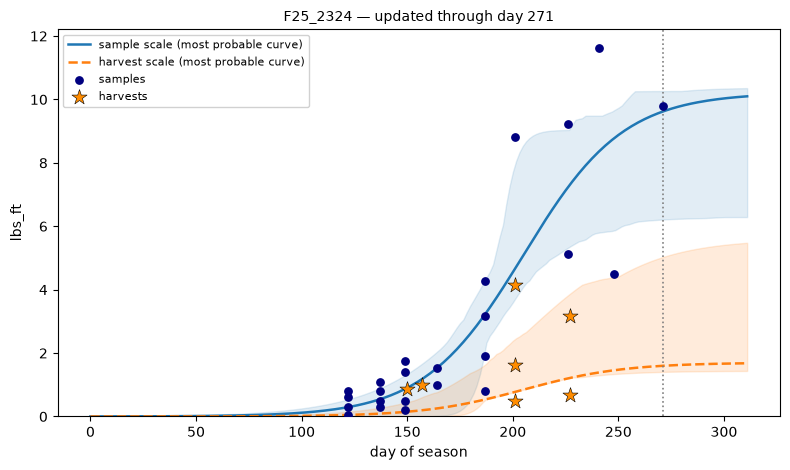

{'A': array([9.925365  , 7.15884654, 9.72581916, ..., 4.73949939, 8.51229268,
        7.15884654], shape=(4000,)),
 'k': array([0.07741607, 0.03863216, 0.04296984, ..., 0.1041388 , 0.04578055,
        0.03863216], shape=(4000,)),
 't0': array([202.55254709, 195.53645614, 208.87728625, ..., 184.91464322,
        197.97343944, 195.53645614], shape=(4000,)),
 'sigma': array([1.50204342, 1.23715849, 1.16499526, ..., 1.19078641, 1.40790988,
        1.23715849], shape=(4000,)),
 'sigma_h': array([1.190993  , 1.30772744, 1.15304761, ..., 1.1336168 , 2.56038823,
        1.30772744], shape=(4000,)),
 'c': array([0.24557524, 0.35360837, 0.58022181, ..., 0.21467461, 0.20153598,
        0.35360837], shape=(4000,)),
 'ess': 31.129990349943068,
 'method': 'sir'}

In [22]:
# season replay / point-in-time forecast with the new plumbing
predict_as_of(events, cloud, "F25_2324", n_obs=30)

In [23]:
# full backtest vs naive (item 6). SIR first for speed; then flip
# POSTERIOR_METHOD (or pass posterior_method="mcmc") and compare — SIR-vs-MCMC
# agreement is a cheap correctness check on both.
backtest, summary = evaluate_biomass_mae(
    events, cloud, curve_name=YIELD_CURVE, c_param=C_PARAM,
    prior_method=PRIOR_METHOD, fallback=PRIOR_FALLBACK,
    posterior_method=POSTERIOR_METHOD, strict_temporal=STRICT_TEMPORAL)
backtest.sort_values("actual_lbs", ascending=False)

/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_19979/2667414957.py:6: RuntimeWarning: overflow encountered in exp
  return A / (1.0 + m.exp(-k * (t - t0)))
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_19979/2667414957.py:6: RuntimeWarning: overflow encountered in exp
  return A / (1.0 + m.exp(-k * (t - t0)))
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_19979/2667414957.py:6: RuntimeWarning: overflow encountered in exp
  return A / (1.0 + m.exp(-k * (t - t0)))
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_19979/2667414957.py:6: RuntimeWarning: overflow encountered in exp
  return A / (1.0 + m.exp(-k * (t - t0)))
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_19979/2667414957.py:6: RuntimeWarning: overflow encountered in exp
  return A / (1.0 + m.exp(-k * (t - t0)))
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_19979/2667414957.py:6: RuntimeWarning: overflow encountered in exp
  return A / (1.0 + m.exp(-k * (t 

Backtest over 78 seasons [prior=kde, posterior=sir, two_curve, point=median]
  model MAE: 5,244 lbs (median 24.6% of actual)
  naive MAE: 5,887 lbs (median 29.3% of actual)
  improvement: +10.9%   model closer in 40/78 seasons


,farm_season_id,farm,season,n_harvests,actual_lbs,model_pred_lbs,naive_pred_lbs,model_abs_err,naive_abs_err,prior_source
47,F55_2223,Farm_55,Season 22/23,1,187541.0,145270.418524,160020.000000,42270.581476,27521.000000,"population KDE (97 seasons, target excluded)"
21,F2_2526,Farm_2,Season 25/26,9,86200.0,74330.577451,84243.958333,11869.422549,1956.041667,"population KDE (97 seasons, target excluded)"
57,F62_2324,Farm_62,Season 23/24,13,79595.0,78465.674556,86587.383333,1129.325444,6992.383333,"population KDE (97 seasons, target excluded)"
66,F70_2324,Farm_70,Season 23/24,7,71522.0,61328.395216,73194.500000,10193.604784,1672.500000,"population KDE (97 seasons, target excluded)"
29,F37_2526,Farm_37,Season 25/26,8,69610.0,66356.306642,87383.146520,3253.693358,17773.146520,"population KDE (97 seasons, target excluded)"
...,...,...,...,...,...,...,...,...,...,...
49,F56_2223,Farm_56,Season 22/23,1,351.0,486.156040,546.480000,135.156040,195.480000,"population KDE (97 seasons, target excluded)"
15,F25_2526,Farm_25,Season 25/26,1,66.0,90.106940,150.400000,24.106940,84.400000,"population KDE (97 seasons, target excluded)"
52,F57_2425,Farm_57,Season 24/25,1,19.0,3.178896,40.000000,15.821104,21.000000,"population KDE (97 seasons, target excluded)"
44,F50_2324,Farm_50,Season 23/24,1,2.2,12875.725766,4330.708800,12873.525766,4328.508800,"population KDE (97 seasons, target excluded)"
